Baseline Accuracy: 0.9048
Tuned Accuracy:    0.9238
Improvement:       +0.0190


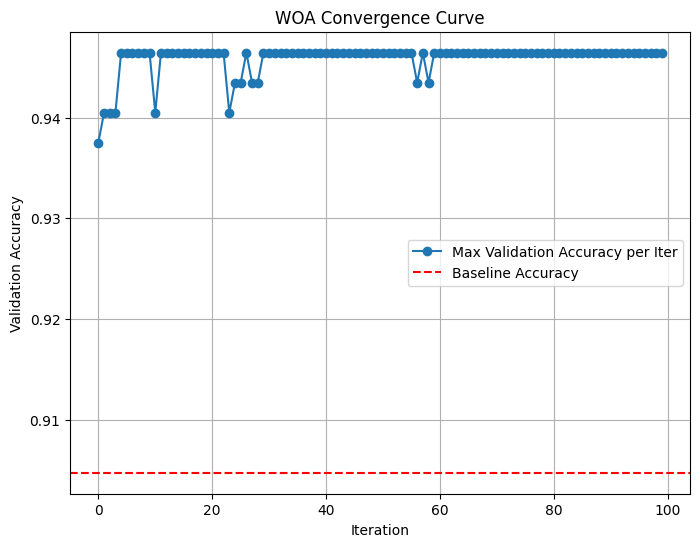

Total Time: 1207.13 sec


In [1]:
import os
import time
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import models, transforms, datasets

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

TRAIN_DIR = './UCMerced_LandUse/Images'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
FEATURES_FILE = 'features_ucmerced.npy'
LABELS_FILE = 'labels_ucmerced.npy'
BEST_PARAMS_FILE = 'best_woa_params_ucmerced.txt'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def extract_features(data_dir):
    if os.path.exists(FEATURES_FILE) and os.path.exists(LABELS_FILE):
        return np.load(FEATURES_FILE), np.load(LABELS_FILE)
    if not os.path.exists(data_dir):
        return None, None

    transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = models.vgg16(pretrained=True).to(DEVICE)
    model.eval()
    feature_extractor = torch.nn.Sequential(*list(model.features.children()))
    feature_extractor.to(DEVICE)
    feature_extractor.eval()

    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(DEVICE)
            output = feature_extractor(imgs)
            output = torch.nn.functional.adaptive_avg_pool2d(output, (1, 1))
            output = output.view(output.size(0), -1)
            features.append(output.cpu().numpy())
            labels.extend(lbls.numpy())

    features = np.concatenate(features)
    labels = np.array(labels)
    np.save(FEATURES_FILE, features)
    np.save(LABELS_FILE, labels)
    return features, labels

def load_and_split_data(features, labels, test_size=0.2, val_size=0.2):
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        features, labels, test_size=test_size, stratify=labels, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, stratify=y_train_full, random_state=42
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def train_baseline_svm(X_train, X_test, y_train, y_test):
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

WOA_PARAMS = {
    'POP_SIZE': 30,
    'MAX_ITER': 100,
    'LB': [1e-3, 1e-4],
    'UB': [100.0, 1.0],
    'V_MAP': [lambda v: 10**v, lambda v: 10**v]
}

def woa_fitness_function(hyperparams, X_train, y_train, X_val, y_val):
    C_raw, gamma_raw = hyperparams
    C = WOA_PARAMS['V_MAP'][0](C_raw)
    gamma = WOA_PARAMS['V_MAP'][1](gamma_raw)
    if C <= 0 or gamma <= 0:
        return 0.0
    model = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return accuracy_score(y_val, y_pred)

def run_whale_optimization(X_train, y_train, X_val, y_val):
    POP_SIZE = WOA_PARAMS['POP_SIZE']
    MAX_ITER = WOA_PARAMS['MAX_ITER']
    LB = np.log10(WOA_PARAMS['LB'])
    UB = np.log10(WOA_PARAMS['UB'])
    DIM = len(LB)

    Position = np.random.uniform(LB, UB, (POP_SIZE, DIM))
    Best_pos = np.zeros(DIM)
    Best_score = -float('inf')
    convergence_curve = []

    for i in range(POP_SIZE):
        score = woa_fitness_function(Position[i, :], X_train, y_train, X_val, y_val)
        if score > Best_score:
            Best_score = score
            Best_pos = Position[i, :].copy()

    for t in range(MAX_ITER):
        a = 2 - t * (2 / MAX_ITER)
        max_score_in_iter = -float('inf')
        for i in range(POP_SIZE):
            r1, r2 = np.random.rand(2)
            A = 2 * a * r1 - a
            C_woa = 2 * r2
            l = np.random.uniform(-1, 1)
            p = np.random.rand()

            if p < 0.5:
                if np.abs(A) < 1:
                    D = np.abs(C_woa * Best_pos - Position[i, :])
                    Position[i, :] = Best_pos - A * D
                else:
                    rand_idx = np.random.randint(0, POP_SIZE)
                    Rand_pos = Position[rand_idx, :]
                    D = np.abs(C_woa * Rand_pos - Position[i, :])
                    Position[i, :] = Rand_pos - A * D
            else:
                D_prime = np.abs(Best_pos - Position[i, :])
                Position[i, :] = D_prime * np.exp(l) * np.cos(2 * np.pi * l) + Best_pos

            Position[i, :] = np.clip(Position[i, :], LB, UB)
            score = woa_fitness_function(Position[i, :], X_train, y_train, X_val, y_val)
            if score > Best_score:
                Best_score = score
                Best_pos = Position[i, :].copy()
            if score > max_score_in_iter:
                max_score_in_iter = score

        convergence_curve.append(max_score_in_iter)

    best_C = WOA_PARAMS['V_MAP'][0](Best_pos[0])
    best_gamma = WOA_PARAMS['V_MAP'][1](Best_pos[1])
    best_params = {'C': best_C, 'gamma': best_gamma}

    with open(BEST_PARAMS_FILE, 'w') as f:
        f.write(f"C: {best_C}\nGamma: {best_gamma}\nBest Val Acc: {Best_score}\n")

    return best_params, convergence_curve

def evaluate_tuned_model(X_train, X_test, y_train, y_test, best_params):
    model = SVC(C=best_params['C'], gamma=best_params['gamma'], kernel='rbf', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

def main():
    start_time = time.time()
    features, labels = extract_features(TRAIN_DIR)
    if features is None:
        return
    X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data(features, labels)
    baseline_acc = train_baseline_svm(X_train, X_test, y_train, y_test)
    best_params, convergence = run_whale_optimization(X_train, y_train, X_val, y_val)
    tuned_acc = evaluate_tuned_model(X_train, X_test, y_train, y_test, best_params)

    print(f"Baseline Accuracy: {baseline_acc:.4f}")
    print(f"Tuned Accuracy:    {tuned_acc:.4f}")
    print(f"Improvement:       {tuned_acc - baseline_acc:+.4f}")

    plt.figure(figsize=(8,6))
    plt.plot(convergence, marker='o', label='Max Validation Accuracy per Iter')
    plt.axhline(y=baseline_acc, color='r', linestyle='--', label='Baseline Accuracy')
    plt.title("WOA Convergence Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Validation Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Total Time: {time.time() - start_time:.2f} sec")

if __name__ == "__main__":
    main()
